In [71]:
import sys 
sys.path.append(os.path.abspath('..'))

In [72]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from src.segmentation import find_digits , crop_digits
from src.preprocessing import preprocess_before_seg , preprocess_digit
import cv2

In [73]:
MODEL_PATH = "../models/digit_classifier_finetuned4.keras"

model = tf.keras.models.load_model(MODEL_PATH)

In [74]:
IMAGE_PATH = "../data/captcha_generated/images/09991.png"

In [75]:
thresh = preprocess_before_seg(IMAGE_PATH)
boxes = find_digits(thresh)
crop= crop_digits(thresh, boxes)

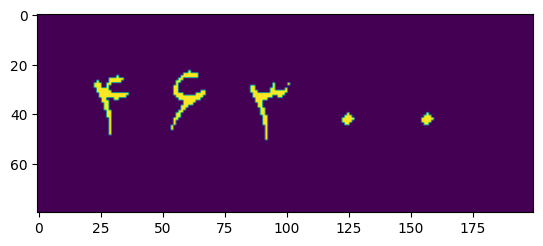

In [76]:
plt.imshow(thresh)

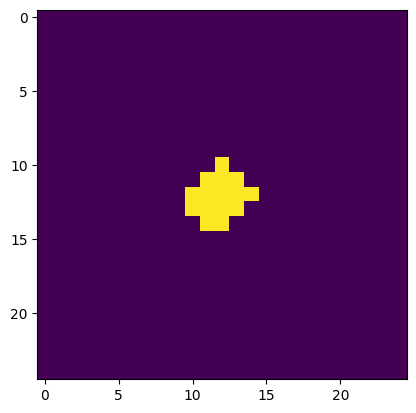

In [77]:
plt.imshow(crop[3])

5


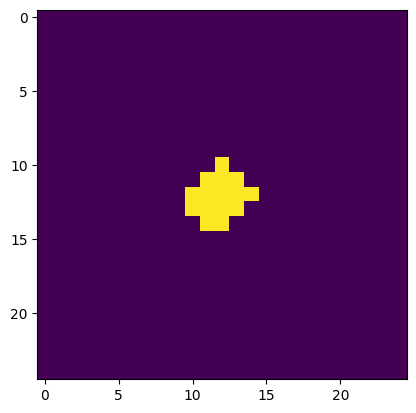

In [78]:
plt.imshow(crop[3])
print(len(crop))

In [79]:
procceed_images = [preprocess_digit(img) for img in crop]

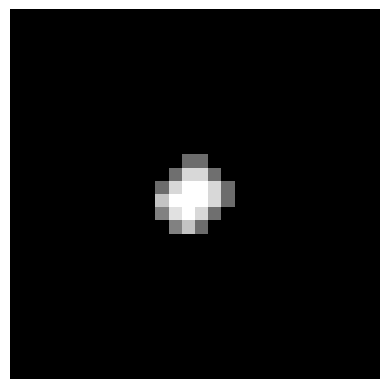

In [80]:
plt.imshow(
    procceed_images[3].squeeze(),
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.axis("off")
plt.show()


In [81]:
tt = np.expand_dims(procceed_images[1], axis=-1)
tt = np.expand_dims(tt, axis=0)
predictions = model.predict(tt)
print(np.argmax(predictions))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
6


In [82]:
print(procceed_images[0].shape)

(28, 28, 1)


In [83]:
for i in procceed_images:
    i = np.expand_dims(i, axis=-1)
    i = np.expand_dims(i, axis=0)
    prediction = model.predict(i)
    predicted_digit = np.argmax(prediction)
    print(f"Predicted digit: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted digit: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predicted digit: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted digit: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted digit: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted digit: 0


In [84]:
print(procceed_images[1].shape)
print(procceed_images[0].min())
print(procceed_images[0].max())

(28, 28, 1)
0.0
1.0
